## Bloque 0
Caso Guía de toda la sesión, una empresa manufacturera necesita un modelo que prediga si una maquina entrará en fallo debido a las condiciones y mediciones pasadas.

* Es un problema de clasificación binaria
* Podria estar desbalanceado

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, TimeSeriesSplit,
    cross_val_score, cross_validate, learning_curve, validation_curve,
)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, classification_report,
    mean_absolute_error, mean_absolute_percentage_error,
    root_mean_squared_error, r2_score,
)

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Entorno listo")

Entorno listo


In [2]:
# Ajuntamos los datos de trabajo
df = pd.read_csv(r"C:\Users\ASUS\Desktop\Proyectos Big data\1. Manufactura\archive\equipment_anomaly_data.csv")
df

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0
...,...,...,...,...,...,...,...
7667,65.711521,37.505934,2.030521,49.331471,Pump,New York,0.0
7668,63.005855,45.164234,1.264585,61.905390,Pump,New York,0.0
7669,72.029230,34.757896,1.709046,49.972917,Pump,Atlanta,0.0
7670,107.086485,23.754114,1.142522,23.967977,Compressor,Atlanta,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   str    
 5   location     7672 non-null   str    
 6   faulty       7672 non-null   float64
dtypes: float64(5), str(2)
memory usage: 534.9 KB


Manejo de Nulos, variables numéricas y categóricas

In [4]:
# Rellenar nulos en variables numéricas (sensores y métricas) con la mediana
columnas_numericas = df.select_dtypes(include=[np.number]).columns
for col in columnas_numericas:
    df[col] = df[col].fillna(df[col].median())

In [5]:
# Rellenar nulos en variables categóricas con un texto predeterminado
columnas_categoricas = ['asset_tag', 'machine_type', 'plant_code','part_description', 'part_family', 'criticality', 'uom']
for col in columnas_categoricas:
    if col in df.columns:
        df[col] = df[col].fillna('No_Registrado')

In [6]:
resumen_columnas = pd.DataFrame({
    'Columna': df.columns,
    'Tipo_Dato': df.dtypes.values,
    'Valores_Nulos': df.isnull().sum().values,
    'Valores_No_Nulos': df.notnull().sum().values,
    'Valores_Unicos': df.nunique().values
})

# 3. Mostrar la tabla organizada en la consola
print("=== RESUMEN GENERAL POR COLUMNA ===")
print(resumen_columnas.to_string(index=False))

# 4. Mostrar filas completamente duplicadas (si las hay)
filas_duplicadas = df.duplicated().sum()
print(f"\nTotal de filas completamente repetidas en el archivo: {filas_duplicadas}")

=== RESUMEN GENERAL POR COLUMNA ===
    Columna Tipo_Dato  Valores_Nulos  Valores_No_Nulos  Valores_Unicos
temperature   float64              0              7672            7672
   pressure   float64              0              7672            7672
  vibration   float64              0              7672            7672
   humidity   float64              0              7672            7672
  equipment       str              0              7672               3
   location       str              0              7672               5
     faulty   float64              0              7672               2

Total de filas completamente repetidas en el archivo: 0


Matriz de confusión

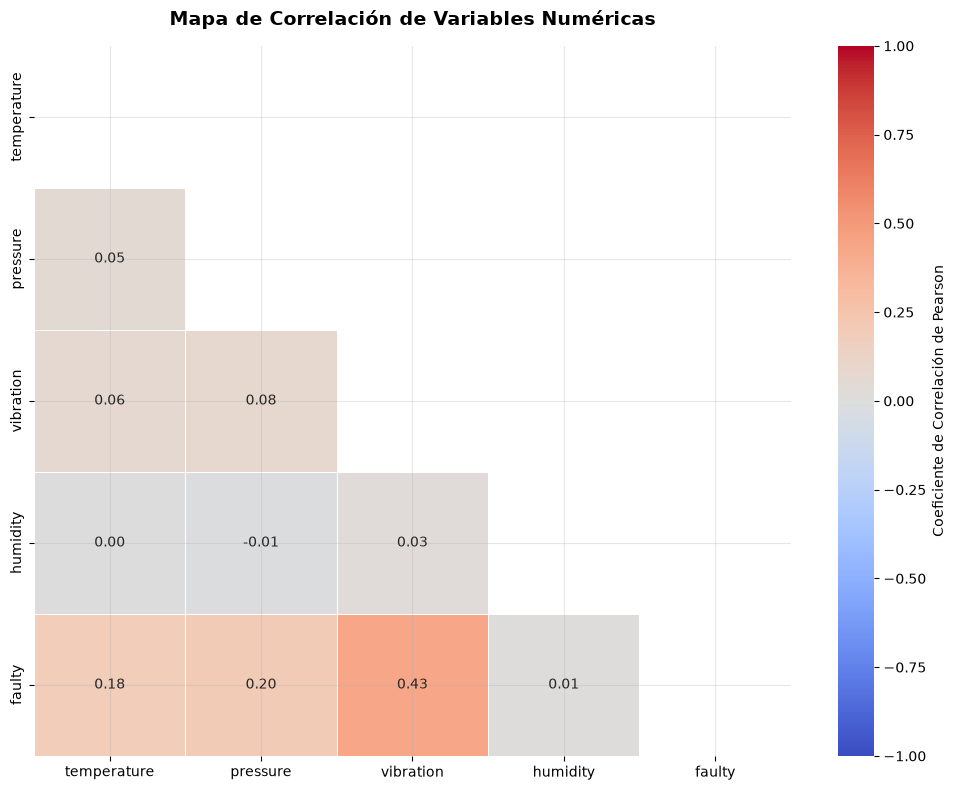

In [7]:
import seaborn as sns

# 1. Cargar el conjunto de datos (asegúrate de colocar el nombre correcto de tu archivo)
# Si es un archivo CSV, usa pd.read_csv('tu_archivo.csv')
#df = pd.read_excel('datos_produccion_limpios.xlsx')

# 2. Seleccionar únicamente las columnas numéricas para el análisis
columnas_numericas = df.select_dtypes(include=[np.number])

# 3. Calcular la matriz de correlación
matriz_corr = columnas_numericas.corr()

# 4. Configurar el tamaño de la figura para una visualización óptima
plt.figure(figsize=(10, 8))

# Crear una máscara para ocultar la mitad superior repetida de la matriz (opcional, para mayor limpieza visual)
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

# Generar el mapa de calor (Heatmap)
sns.heatmap(
    matriz_corr, 
    mask=mascara, 
    annot=True,          # Muestra los valores numéricos dentro de cada celda
    fmt='.2f',           # Formato de dos decimales
    cmap='coolwarm',     # Paleta de colores (azul para negativo, rojo para positivo)
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,      # Líneas divisorias entre celdas
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)

plt.title('Mapa de Correlación de Variables Numéricas', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Guardar la imagen en alta calidad
plt.savefig('mapa_correlacion_completo.png', dpi=300)
plt.show()

In [8]:
df.describe()

,temperature,pressure,vibration,humidity,faulty
count,7672.000000,7672.000000,7672.000000,7672.000000,7672.000000
mean,70.922478,35.738048,1.611809,50.016574,0.099974
std,16.200059,10.381593,0.728560,11.841479,0.299985
min,10.269385,3.620798,-0.428188,10.215077,0.000000
25%,62.777057,29.485682,1.170906,42.612817,0.000000
50%,70.156900,35.227544,1.533113,50.024744,0.000000
75%,77.568387,41.159913,1.924700,57.340513,0.000000
max,149.690420,79.887734,4.990537,89.984718,1.000000


## Procesamiento de Datos

In [9]:
# Columnas numéricas de interes para el análisis
num_cols = ['temperature', 'pressure', 'vibration', 'humidity']

In [10]:
df_processed = pd.get_dummies(df, columns=['equipment', 'location'], drop_first=True)

In [11]:
df_processed.head()

,temperature,pressure,vibration,humidity,faulty,equipment_Pump,equipment_Turbine,location_Chicago,location_Houston,location_New York,location_San Francisco
0,58.180180,25.029278,0.606516,45.694907,0.0,False,True,False,False,False,False
1,75.740712,22.954018,2.338095,41.867407,0.0,False,False,True,False,False,False
2,71.358594,27.276830,1.389198,58.954409,0.0,False,True,False,False,False,True
3,71.616985,32.242921,1.770690,40.565138,0.0,True,False,False,False,False,False
4,66.506832,45.197471,0.345398,43.253795,0.0,True,False,False,False,True,False


In [12]:
X = df_processed.drop('faulty', axis=1)
y = df_processed['faulty']

In [13]:
# convertir a numpy arrays para compatibilidad con TensorFlow
print(type(X))

Xarray = X.to_numpy().astype('float32')
print(type(Xarray))
print(Xarray.shape)

Yarray = y.to_numpy().astype('float32')
print(type(Yarray))
print(Yarray.shape)

<class 'pandas.DataFrame'>
<class 'numpy.ndarray'>
(7672, 10)
<class 'numpy.ndarray'>
(7672,)


## Bloque 1 -- El problema de la generalización

El instinto inicial es partir los datos en dos: 80 % entrena, 20 % evalúa. El problema es que
ese 20 % es **una muestra aleatoria**, y por lo tanto la métrica que produce **también es una
variable aleatoria**. Si repetimos la partición cambiando la semilla, obtenemos números
distintos. La pregunta de clase es: *¿qué tan distintos?*

> **Pregunta para los alumnos antes de correr la celda:** si el AUC "real" del modelo es 0.85,
> ¿cuánto creen que puede variar el AUC medido con un solo split de 800 registros? ¿±0.01? ¿±0.05?

## Sin escala

aucs = []
for semilla in range(40):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=semilla, stratify=y
    )
    modelo = LogisticRegression(max_iter=2000).fit(X_tr, y_tr)
    aucs.append(roc_auc_score(y_te, modelo.predict_proba(X_te)[:, 1]))

aucs = np.array(aucs)
print(f"AUC mínimo : {aucs.min():.4f}")
print(f"AUC máximo : {aucs.max():.4f}")
print(f"Media      : {aucs.mean():.4f}")
print(f"Desv. est. : {aucs.std():.4f}")
print(f"Rango      : {aucs.max() - aucs.min():.4f}  <-- misma data, mismo modelo")

In [14]:
## Con escala

In [15]:
aucs = []

for semilla in range(40):
    # Separar en entrenamiento y prueba con estratificación
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=semilla, stratify=y
    )
    
    # 4. Escalar los datos correctamente (fit solo en train, transform en train y test)
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    
    # 5. Entrenar el modelo de Regresión Logística
    modelo = LogisticRegression(max_iter=2000)
    modelo.fit(X_tr_scaled, y_tr)
    
    # 6. Evaluar y guardar el AUC en el conjunto de prueba
    score_auc = roc_auc_score(y_te, modelo.predict_proba(X_te_scaled)[:, 1])
    aucs.append(score_auc)

# 7. Convertir a arreglo de NumPy para calcular métricas estadísticas
aucs = np.array(aucs)

# 8. Mostrar los resultados finales
print(f"AUC mínimo : {aucs.min():.4f}")
print(f"AUC máximo : {aucs.max():.4f}")
print(f"Media      : {aucs.mean():.4f}")
print(f"Desv. est. : {aucs.std():.4f}")
print(f"Rango      : {aucs.max() - aucs.min():.4f} <-- misma data, mismo modelo")

AUC mínimo : 0.7117
AUC máximo : 0.8030
Media      : 0.7627
Desv. est. : 0.0211
Rango      : 0.0913 <-- misma data, mismo modelo


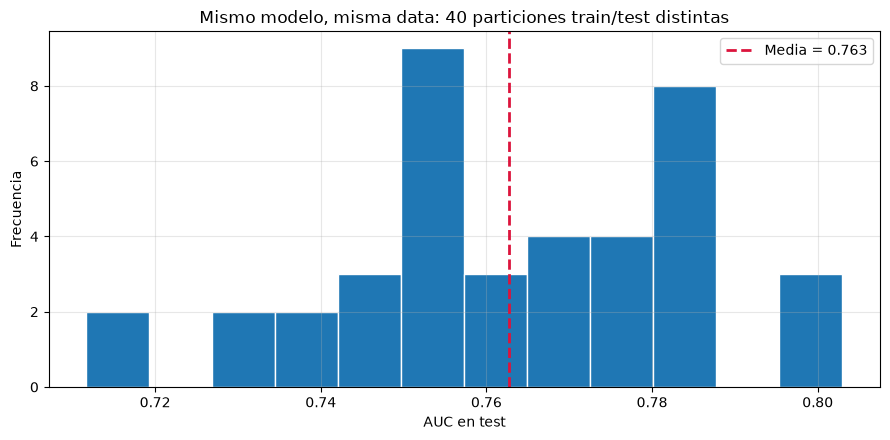

In [16]:
fig, ax = plt.subplots()
ax.hist(aucs, bins=12, edgecolor="white")
ax.axvline(aucs.mean(), color="crimson", ls="--", lw=2, label=f"Media = {aucs.mean():.3f}")
ax.set_title("Mismo modelo, misma data: 40 particiones train/test distintas")
ax.set_xlabel("AUC en test")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

## Lectura del resultado
Cambiando únicamente la semilla, el AUC se mueve varios puntos. Si un analista reporta
"mi modelo tiene 0.87 de AUC" con un solo split, **está reportando un punto de esa
distribución, probablemente el que más le gustó**.

La validación cruzada resuelve esto: en vez de un número, obtenemos una **media y una
desviación**, es decir, una estimación con su incertidumbre.


## Bloque 2  K-Fold Cross Validation

**K-Fold** divide el dataset en $k$ particiones (*folds*) del mismo tamaño. Se entrena $k$ veces:
en cada iteración un fold distinto actúa como validación y los $k-1$ restantes como
entrenamiento. El resultado es un vector de $k$ métricas.

$$\text{CV}_{(k)} = \frac{1}{k}\sum_{i=1}^{k} \text{métrica}_i$$

**Ventajas:** cada observación se usa exactamente una vez para validar; la estimación tiene
mucha menos varianza; obtenemos una barra de error.

**Costo:** entrenar $k$ veces. Con $k=5$ el costo computacional se multiplica por 5.

**¿Qué valor de k?** En la práctica 5 o 10. Con $k$ muy alto (ej. Leave-One-Out, $k=n$) el
sesgo baja pero la varianza sube y el costo se dispara.

In [17]:
# Paso 1: ver los índices "a mano" para que quede claro qué hace K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"{'Fold':<6}{'N entrenamiento':>18}{'N validación':>15}   Primeros índices de validación")
for i, (idx_tr, idx_va) in enumerate(kf.split(X), start=1):
    print(f"{i:<6}{len(idx_tr):>18,}{len(idx_va):>15,}   {idx_va[:5]}")

Fold     N entrenamiento   N validación   Primeros índices de validación
1                  6,137          1,535   [ 0  8 14 17 19]
2                  6,137          1,535   [12 15 26 29 30]
3                  6,138          1,534   [ 6 18 24 25 32]
4                  6,138          1,534   [ 1  2  7 10 11]
5                  6,138          1,534   [ 3  4  5  9 16]


In [18]:
# Paso 2: la forma corta
modelo = LogisticRegression(max_iter=2000)
scores = cross_val_score(modelo, X, y, cv=kf, scoring="roc_auc")

print("AUC por fold:", np.round(scores, 4))
print(f"\nAUC = {scores.mean():.4f} ± {scores.std():.4f}")
print(f"IC aproximado 95%: [{scores.mean() - 2*scores.std():.4f}, {scores.mean() + 2*scores.std():.4f}]")

AUC por fold: [0.7778 0.7419 0.8082 0.7222 0.7827]

AUC = 0.7666 ± 0.0306
IC aproximado 95%: [0.7053, 0.8278]


### `cross_validate`: varias métricas de una sola pasada

`cross_val_score` devuelve una métrica. `cross_validate` devuelve varias, más los tiempos, y
opcionalmente el score de entrenamiento — **que es clave para detectar overfitting**.

In [19]:
resultados = cross_validate(
    LogisticRegression(max_iter=2000),
    X, y, cv=kf,
    scoring=["roc_auc", "average_precision", "f1", "recall", "precision"],
    return_train_score=True,
)

tabla = pd.DataFrame({
    "Métrica": ["roc_auc", "average_precision", "f1", "recall", "precision"],
    "Train": [resultados[f"train_{m}"].mean() for m in
              ["roc_auc", "average_precision", "f1", "recall", "precision"]],
    "Validación": [resultados[f"test_{m}"].mean() for m in
                   ["roc_auc", "average_precision", "f1", "recall", "precision"]],
    "Desv. val.": [resultados[f"test_{m}"].std() for m in
                   ["roc_auc", "average_precision", "f1", "recall", "precision"]],
}).round(4)
tabla["Gap (train - val)"] = (tabla["Train"] - tabla["Validación"]).round(4)
tabla

,Métrica,Train,Validación,Desv. val.,Gap (train - val)
0,roc_auc,0.7701,0.7666,0.0306,0.0035
1,average_precision,0.6410,0.6399,0.0253,0.0011
2,f1,0.5718,0.5649,0.0246,0.0069
3,recall,0.4025,0.3966,0.0236,0.0059
4,precision,0.9873,0.9836,0.0106,0.0037


### Comparar modelos correctamente

Regla: **los modelos se comparan sobre los mismos folds**. Si cada modelo se evalúa con una
partición distinta, la diferencia observada puede deberse a la partición y no al modelo.

In [20]:
candidatos = {
    "Regresión Logística": Pipeline([("sc", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=2000))]),
    "Árbol (prof. 3)": DecisionTreeClassifier(max_depth=3, random_state=SEED),
    "Árbol (sin podar)": DecisionTreeClassifier(random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
}

comparacion = []
for nombre, mod in candidatos.items():
    s = cross_val_score(mod, X, y, cv=kf, scoring="roc_auc")  # mismo objeto kf para todos
    comparacion.append({"Modelo": nombre, "AUC medio": s.mean(), "Desv.": s.std(),
                        "Peor fold": s.min(), "Mejor fold": s.max()})

df_comp = pd.DataFrame(comparacion).sort_values("AUC medio", ascending=False).round(4)
df_comp

,Modelo,AUC medio,Desv.,Peor fold,Mejor fold
3,Random Forest,0.9787,0.0068,0.9697,0.9896
2,Árbol (sin podar),0.9245,0.0070,0.9187,0.9379
1,Árbol (prof. 3),0.8780,0.0220,0.8574,0.9186
0,Regresión Logística,0.7665,0.0306,0.7221,0.8082


# Resumen de Comparativa de Modelos (Validación Cruzada)

La siguiente tabla resume el rendimiento de los modelos evaluados según su **AUC medio**, estabilidad (**Desviación estándar**) y sus extremos por *fold*[cite: 8]:

| Modelo | AUC medio | Desv. | Peor fold | Mejor fold |
| :--- | :---: | :---: | :---: | :---: |
| **Random Forest** | **0.9787** | **0.0068** | 0.9697 | 0.9896 |
| **Árbol (sin podar)** | 0.9245 | 0.0070 | 0.9187 | 0.9379 |
| **Árbol (prof. 3)** | 0.8780 | 0.0220 | 0.8574 | 0.9186 |
| **Regresión Logística** | 0.7665 | 0.0306 | 0.7221 | 0.8082 |

## Conclusiones clave:
1. **Mejor Modelo:** **Random Forest** domina ampliamente con un **AUC de 0.9787** y la menor dispersión (desviación de 0.0068), demostrando máxima precisión y estabilidad[cite: 8].
2. **Árboles de Decisión:** Superan significativamente a la Regresión Logística, aunque el árbol sin restricciones muestra indicios de posible sobreajuste frente a configuraciones más controladas.
3. **Regresión Logística:** Queda rezagada como el modelo base con el rendimiento más bajo (AUC de 0.7665) y mayor variabilidad entre particiones[cite: 8].

## Bloque 3 - Stratified K-Fold

Con clases desbalanceadas, un K-Fold aleatorio puede producir folds con proporciones muy
distintas de la clase minoritaria. En un caso extremo (fraude al 0.5 %, folds pequeños) puede
haber folds **sin ningún caso positivo**, y ahí métricas como AUC o recall no están definidas.

**Stratified K-Fold** preserva la proporción de clases en cada fold. Para clasificación es el
comportamiento por defecto de scikit-learn cuando pasamos `cv=5` como entero — pero conviene
hacerlo explícito.

In [21]:
# 1. Definir X e y con tu dataset ya procesado
X = df.drop(columns=["faulty"])
y = df["faulty"]

print(f"Tasa de fallas global: {y.mean():.2%} ({int(y.sum())} casos positivos de {len(y)})")

# 2. Inicializar los validadores
filas = []
kf_simple = KFold(n_splits=5, shuffle=True, random_state=3)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)

# 3. Iterar comparando KFold vs StratifiedKFold
for i, ((_, va_k), (_, va_s)) in enumerate(zip(kf_simple.split(X, y), skf.split(X, y)), 1):
    filas.append({
        "Fold": i,
        "KFold - % fallas": y.iloc[va_k].mean(),
        "KFold - n positivos": int(y.iloc[va_k].sum()),
        "Stratified - % fallas": y.iloc[va_s].mean(),
        "Stratified - n positivos": int(y.iloc[va_s].sum()),
    })

# 4. Mostrar la tabla comparativa redondeada
df_estrat = pd.DataFrame(filas)
df_estrat[["KFold - % fallas", "Stratified - % fallas"]] = \
    df_estrat[["KFold - % fallas", "Stratified - % fallas"]].round(4)

df_estrat

Tasa de fallas global: 10.00% (767 casos positivos de 7672)


,Fold,KFold - % fallas,KFold - n positivos,Stratified - % fallas,Stratified - n positivos
0,1,0.1062,163,0.1003,154
1,2,0.0951,146,0.1003,154
2,3,0.1010,155,0.0997,153
3,4,0.0965,148,0.0997,153
4,5,0.1010,155,0.0997,153


In [25]:
# 1. Asegurar que X e y estén limpios y 100% numéricos
X = pd.get_dummies(df.drop(columns=["faulty"]), drop_first=True)
y = df["faulty"]

# 2. Correr los modelos con validación cruzada
mod = LogisticRegression(max_iter=2000)

s_kf = cross_val_score(mod, X, y, cv=kf_simple, scoring="roc_auc")
s_skf = cross_val_score(mod, X, y, cv=skf, scoring="roc_auc")

print(f"KFold     → AUC {s_kf.mean():.4f} ± {s_kf.std():.4f}  (rango [{s_kf.min():.3f}, {s_kf.max():.3f}])")
print(f"Stratified → AUC {s_skf.mean():.4f} ± {s_skf.std():.4f}  (rango [{s_skf.min():.3f}, {s_skf.max():.3f}])")

print("\nLa media puede parecerse; lo que mejora es la ESTABILIDAD entre folds.")

KFold     → AUC 0.7656 ± 0.0124  (rango [0.745, 0.778])
Stratified → AUC 0.7649 ± 0.0433  (rango [0.691, 0.818])

La media puede parecerse; lo que mejora es la ESTABILIDAD entre folds.


### Regla práctica

| Situación | Estrategia |
|---|---|
| Clasificación (siempre) | `StratifiedKFold` |
| Regresión | `KFold` con `shuffle=True` |
| Datos agrupados (varios registros por cliente) | `GroupKFold` / `StratifiedGroupKFold` |
| Datos con orden temporal | `TimeSeriesSplit` (Bloque 4) |

> **Advertencia sobre datos agrupados:** si un mismo cliente aparece en 12 meses distintos y
> repartimos las filas al azar, el modelo ve al mismo cliente en train y en validación. El AUC
> sube y el modelo fracasa en producción. Para eso existe `GroupKFold`.

---
## Bloque 4 — Time Series Cross Validation

### Teoría

Con datos temporales, la validación aleatoria **entrena con el futuro para predecir el
pasado**. Eso es imposible en producción y produce métricas infladas.

`TimeSeriesSplit` respeta el orden: cada fold entrena con el pasado y valida con el bloque
inmediatamente posterior (ventana expansiva):

```
Fold 1:  [train train] [val] . . . . . .
Fold 2:  [train train train train] [val] . . . .
Fold 3:  [train train train train train train] [val] . .
```

Además existe el concepto de **gap**: si la variable objetivo se observa 3 meses después
(como la mora a 90 días), hay que dejar un espacio entre train y validación para no usar
información que en la práctica todavía no estaría disponible.

## Bloque 5 — Data leakage y Pipelines

### Teoría

**Fuga de información (leakage)** ocurre cuando información de la partición de validación
influye en el entrenamiento. El síntoma es siempre el mismo: **métricas excelentes en
validación y desempeño pobre en producción**.

Las tres fuentes más comunes:

1. **Preprocesamiento sobre todo el dataset.** Escalar, imputar nulos o codificar categorías
   usando la media/varianza de *todos* los datos filtra información de validación.
2. **Selección de variables antes de partir.** Elegir las "mejores" features mirando todo el
   dataset es la fuga más severa y la más frecuente.
3. **Variables del futuro.** Incluir un campo que en producción solo existe *después* de que
   ocurrió el evento (ej. `fecha_castigo` para predecir mora).

La solución técnica es el **`Pipeline`**: encapsula preprocesamiento + modelo en un solo
objeto, y `cross_val_score` lo re-ajusta *dentro* de cada fold.

### Demostración extrema: datos 100 % ruido

Generamos 200 observaciones con 5 000 variables **puramente aleatorias** y un target
**aleatorio**. No existe ninguna señal. Un modelo honesto debe dar AUC ≈ 0.50.

In [26]:
rng = np.random.default_rng(7)
X_ruido = rng.normal(size=(200, 5000))
y_ruido = rng.integers(0, 2, size=200)

# INCORRECTO: seleccionar las 20 "mejores" variables mirando TODO el dataset
selector = SelectKBest(f_classif, k=20).fit(X_ruido, y_ruido)
X_preseleccionado = selector.transform(X_ruido)
auc_mal = cross_val_score(LogisticRegression(max_iter=2000), X_preseleccionado, y_ruido,
                          cv=5, scoring="roc_auc").mean()

# CORRECTO: la selección ocurre dentro de cada fold
pipe_ok = Pipeline([
    ("seleccion", SelectKBest(f_classif, k=20)),
    ("clf", LogisticRegression(max_iter=2000)),
])
auc_bien = cross_val_score(pipe_ok, X_ruido, y_ruido, cv=5, scoring="roc_auc").mean()

print("Datos: 100% ruido aleatorio. El AUC verdadero es 0.50\n")
print(f"  Selección FUERA del pipeline (incorrecto) → AUC {auc_mal:.4f}")
print(f"  Selección DENTRO del pipeline (correcto)  → AUC {auc_bien:.4f}")
print("\nEl primer número es completamente ficticio. Y así se aprueban modelos en comités.")

Datos: 100% ruido aleatorio. El AUC verdadero es 0.50

  Selección FUERA del pipeline (incorrecto) → AUC 0.9040
  Selección DENTRO del pipeline (correcto)  → AUC 0.5164

El primer número es completamente ficticio. Y así se aprueban modelos en comités.


In [27]:
# Plantilla correcta de trabajo
pipeline_produccion = Pipeline([
    ("escalado", StandardScaler()),
    ("seleccion", SelectKBest(f_classif, k=6)),
    ("modelo", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

scores_pipe = cross_val_score(pipeline_produccion, X, y,
                              cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                              scoring="roc_auc")
print(f"Pipeline completo → AUC {scores_pipe.mean():.4f} ± {scores_pipe.std():.4f}")
print("\nRegla: TODO lo que aprenda parámetros de los datos va dentro del Pipeline.")

Pipeline completo → AUC 0.7684 ± 0.0355

Regla: TODO lo que aprenda parámetros de los datos va dentro del Pipeline.


---
## Bloque 6 — Bias vs Variance, Overfitting y Underfitting

### Teoría

El error esperado de un modelo se descompone en tres partes:

$$\mathbb{E}\big[(y - \hat{f}(x))^2\big] = \underbrace{\text{Bias}^2}_{\text{error sistemático}} + \underbrace{\text{Varianza}}_{\text{sensibilidad a la muestra}} + \underbrace{\sigma^2}_{\text{ruido irreducible}}$$

- **Bias alto (underfitting):** el modelo es demasiado simple para capturar la relación real.
  Error alto en entrenamiento *y* en validación.
- **Varianza alta (overfitting):** el modelo memoriza la muestra, incluido el ruido.
  Error bajo en entrenamiento, alto en validación.
- **Ruido irreducible:** no se elimina con ningún modelo. Es el piso.

Existe un **trade-off**: aumentar la complejidad baja el bias y sube la varianza. El objetivo
no es minimizar ninguno de los dos, sino **su suma**.

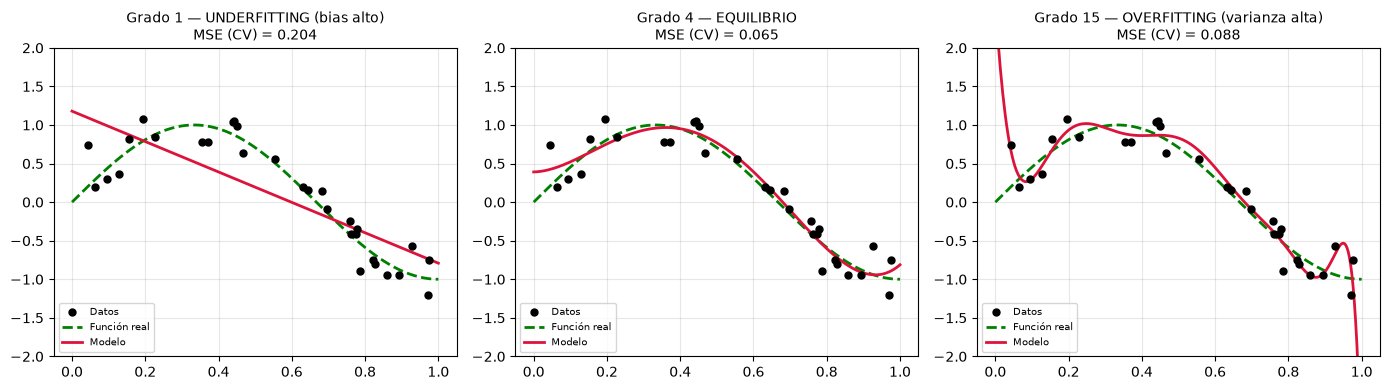

In [28]:
# Demostración visual con regresión polinómica
def f_real(x):
    return np.sin(1.5 * np.pi * x)


rng = np.random.default_rng(SEED)
x_train = np.sort(rng.uniform(0, 1, 30))
y_train = f_real(x_train) + rng.normal(0, 0.25, 30)
x_plot = np.linspace(0, 1, 300)

grados = [1, 4, 15]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, g in zip(axes, grados):
    modelo_poly = Pipeline([("poly", PolynomialFeatures(g)), ("lin", LinearRegression())])
    modelo_poly.fit(x_train.reshape(-1, 1), y_train)
    y_pred_plot = modelo_poly.predict(x_plot.reshape(-1, 1))

    mse_cv = -cross_val_score(modelo_poly, x_train.reshape(-1, 1), y_train,
                              cv=KFold(5, shuffle=True, random_state=SEED),
                              scoring="neg_mean_squared_error").mean()

    ax.scatter(x_train, y_train, s=25, c="black", zorder=3, label="Datos")
    ax.plot(x_plot, f_real(x_plot), "g--", lw=2, label="Función real")
    ax.plot(x_plot, y_pred_plot, "crimson", lw=2, label="Modelo")
    ax.set_ylim(-2, 2)
    diagnostico = {1: "UNDERFITTING (bias alto)", 4: "EQUILIBRIO", 15: "OVERFITTING (varianza alta)"}[g]
    ax.set_title(f"Grado {g} — {diagnostico}\nMSE (CV) = {mse_cv:.3f}", fontsize=10)
    ax.legend(fontsize=7, loc="lower left")

plt.tight_layout()
plt.show()

### Curva de validación: error vs complejidad

Fija el modelo y varía **un hiperparámetro**. Es el diagnóstico más directo del trade-off.
(En la Sesión 2 automatizamos esta búsqueda con Grid Search.)

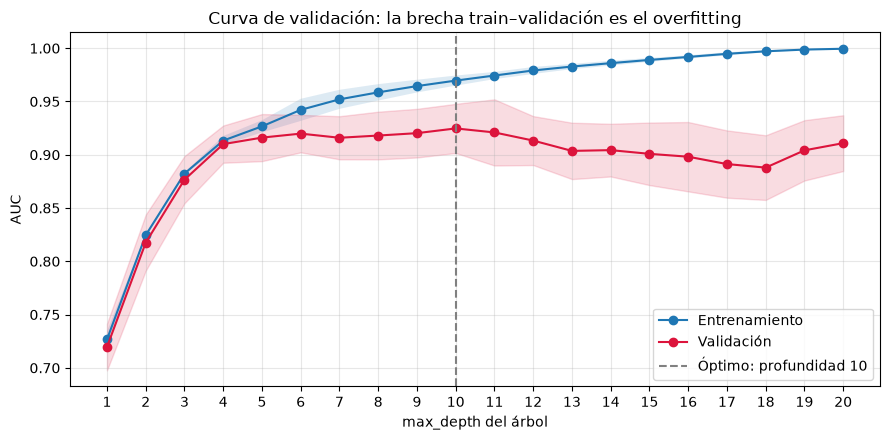

Profundidad óptima: 10  →  AUC validación = 0.9247


In [29]:
rango_prof = range(1, 21)
train_sc, val_sc = validation_curve(
    DecisionTreeClassifier(random_state=SEED), X, y,
    param_name="max_depth", param_range=list(rango_prof),
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring="roc_auc", n_jobs=-1,
)

fig, ax = plt.subplots()
ax.plot(rango_prof, train_sc.mean(1), "o-", label="Entrenamiento")
ax.fill_between(rango_prof, train_sc.mean(1) - train_sc.std(1),
                train_sc.mean(1) + train_sc.std(1), alpha=0.15)
ax.plot(rango_prof, val_sc.mean(1), "o-", color="crimson", label="Validación")
ax.fill_between(rango_prof, val_sc.mean(1) - val_sc.std(1),
                val_sc.mean(1) + val_sc.std(1), alpha=0.15, color="crimson")
mejor = list(rango_prof)[int(np.argmax(val_sc.mean(1)))]
ax.axvline(mejor, ls="--", color="gray", label=f"Óptimo: profundidad {mejor}")
ax.set(xlabel="max_depth del árbol", ylabel="AUC",
       title="Curva de validación: la brecha train–validación es el overfitting")
ax.set_xticks(list(rango_prof))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Profundidad óptima: {mejor}  →  AUC validación = {val_sc.mean(1).max():.4f}")

A partir de los resultados visualizados:
* Curva de Entrenamiento (azul): El rendimiento aumenta de forma constante a medida que el árbol se vuelve más complejo y profundo, acercándose a un AUC perfecto de 1.0.
* Curva de Validación (rojo): El puntaje mejora al principio, pero a partir de cierta profundidad comienza a estancarse o disminuir ligeramente debido al sobreajuste (overfitting), ensanchando la brecha con respecto al entrenamiento. 

  Punto Óptimo: El algoritmo determinó que la profundidad óptima es 10, alcanzando un rendimiento máximo en validación con un AUC de 0.9247. 

In [ ]:
### Curva de aprendizaje: error vs cantidad de datos

Responde a la pregunta gerencial más común: **"¿conseguir más datos mejorará el modelo?"**

- Curvas que **convergen y se aplanan alto** → más datos no ayudan; el modelo es adecuado.
- Curvas que **convergen y se aplanan bajo** → underfitting; hace falta un modelo más complejo
  o mejores variables. Más datos **no** sirven.
- Curvas con **brecha amplia que se va cerrando** → overfitting; más datos **sí** ayudan.

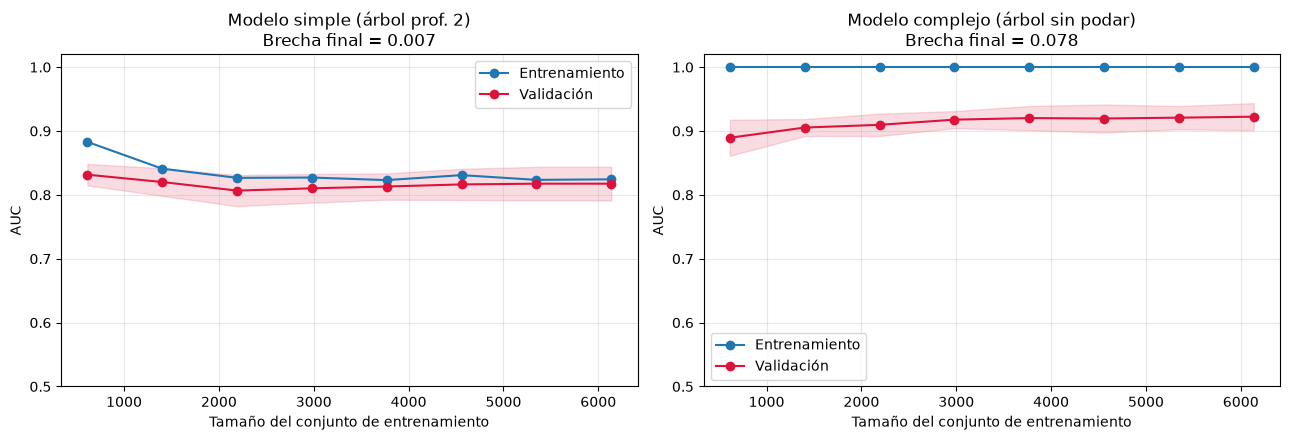

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
configuraciones = [
    ("Modelo simple (árbol prof. 2)", DecisionTreeClassifier(max_depth=2, random_state=SEED)),
    ("Modelo complejo (árbol sin podar)", DecisionTreeClassifier(random_state=SEED)),
]

for ax, (nombre, mod) in zip(axes, configuraciones):
    tam, tr_s, va_s = learning_curve(
        mod, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
        train_sizes=np.linspace(0.1, 1.0, 8), scoring="roc_auc", n_jobs=-1,
    )
    ax.plot(tam, tr_s.mean(1), "o-", label="Entrenamiento")
    ax.plot(tam, va_s.mean(1), "o-", color="crimson", label="Validación")
    ax.fill_between(tam, va_s.mean(1) - va_s.std(1), va_s.mean(1) + va_s.std(1),
                    alpha=0.15, color="crimson")
    brecha = tr_s.mean(1)[-1] - va_s.mean(1)[-1]
    ax.set(xlabel="Tamaño del conjunto de entrenamiento", ylabel="AUC",
           title=f"{nombre}\nBrecha final = {brecha:.3f}", ylim=(0.5, 1.02))
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
Estas dos curvas de aprendizaje comparan cómo evoluciona el rendimiento del modelo a medida que aumenta el tamaño de los datos de entrenamiento:

## Modelo simple (Árbol profundidad 2):

Presenta una brecha final muy pequeña (0.007) entre entrenamiento y validación.

Ambas curvas se mantienen juntas y estables, lo que indica que el modelo es consistente pero tiene una capacidad limitada (puede sufrir un ligero underfitting o subajuste).

## Modelo complejo (Árbol sin podar):

Muestra una brecha final amplia (0.078).

La línea de entrenamiento se clava perfectamente en 1.0 de AUC, mientras que la validación se queda más abajo, evidenciando sobreajuste (overfitting) debido a que el árbol memoriza los datos sin restricciones complejas.

findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmti10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


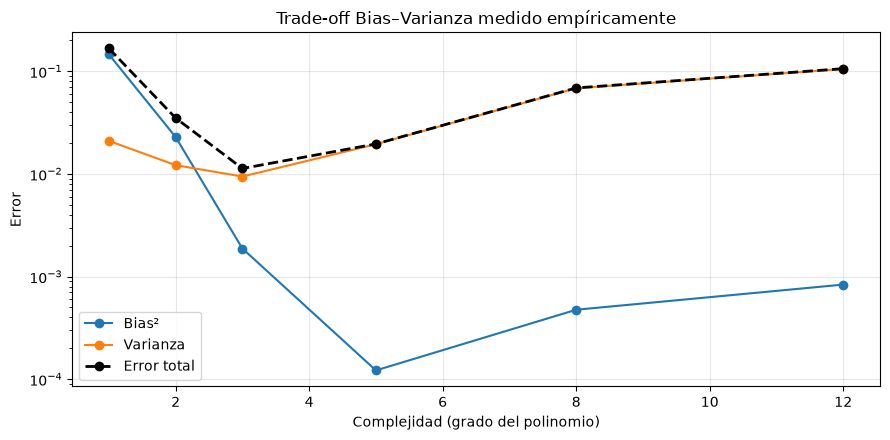

,Grado,Bias²,Varianza,Bias² + Varianza
0,1,0.1462,0.0210,0.1672
1,2,0.0229,0.0122,0.0351
2,3,0.0019,0.0094,0.0113
3,5,0.0001,0.0195,0.0196
4,8,0.0005,0.0685,0.0689
5,12,0.0008,0.1054,0.1062


In [32]:
# Descomposición bias-variance empírica sobre un punto
def descomponer(grado, n_simulaciones=200, n_muestra=30):
    """Estima bias^2 y varianza repitiendo el entrenamiento sobre muestras distintas."""
    rng_local = np.random.default_rng(1)
    x_eval = np.linspace(0.05, 0.95, 50).reshape(-1, 1)
    predicciones = np.zeros((n_simulaciones, len(x_eval)))

    for s in range(n_simulaciones):
        x_s = rng_local.uniform(0, 1, n_muestra)
        y_s = f_real(x_s) + rng_local.normal(0, 0.25, n_muestra)
        m = Pipeline([("poly", PolynomialFeatures(grado)), ("lin", Ridge(alpha=1e-8))])
        m.fit(x_s.reshape(-1, 1), y_s)
        predicciones[s] = m.predict(x_eval)

    pred_media = predicciones.mean(axis=0)
    bias2 = np.mean((pred_media - f_real(x_eval.ravel())) ** 2)
    varianza = np.mean(predicciones.var(axis=0))
    return bias2, varianza


filas_bv = []
for g in [1, 2, 3, 5, 8, 12]:
    b2, v = descomponer(g)
    filas_bv.append({"Grado": g, "Bias²": b2, "Varianza": v, "Bias² + Varianza": b2 + v})

df_bv = pd.DataFrame(filas_bv)
fig, ax = plt.subplots()
ax.plot(df_bv["Grado"], df_bv["Bias²"], "o-", label="Bias²")
ax.plot(df_bv["Grado"], df_bv["Varianza"], "o-", label="Varianza")
ax.plot(df_bv["Grado"], df_bv["Bias² + Varianza"], "ko--", lw=2, label="Error total")
ax.set(xlabel="Complejidad (grado del polinomio)", ylabel="Error", yscale="log",
       title="Trade-off Bias–Varianza medido empíricamente")
ax.legend()
plt.tight_layout()
plt.show()

df_bv.round(4)

# Trade-off Bias-Varianza medido empíricamente

Esta gráfica y su tabla correspondiente ilustran de forma empírica el clásico **dilema entre el sesgo y la varianza (*Bias-Variance Trade-off*)** en función de la complejidad del modelo (representada por el grado del polinomio).

## Componentes principales

* **Sesgo al cuadrado ($\text{Bias}^2$ - línea azul):** Representa el error por modelos demasiado simples que no logran capturar la tendencia de los datos (subajuste). Disminuye a medida que aumenta la complejidad.
* **Varianza (línea naranja):** Mide qué tan sensible es el modelo a las fluctuaciones en los datos de entrenamiento. Aumenta drásticamente conforme el modelo se vuelve más complejo.
* **Error total (línea negra punteada):** Es la suma de ambos componentes ($\text{Bias}^2 + \text{Varianza}$).

## Análisis de los resultados de la tabla

* **Punto óptimo (Grado 3):** El error total alcanza su valor más bajo ($0.0113$), logrando el mejor equilibrio donde el sesgo es bajo ($0.0019$) y la varianza se mantiene controlada ($0.0094$).
* **Sobreajuste (*Overfitting* - Grados 8 y 12):** A partir del grado 5, aunque el sesgo se reduce al mínimo, **la varianza se dispara de forma masiva** (hasta $0.1054$ en el grado 12), provocando que el error total vuelva a subir debido a que el modelo se vuelve inestable ante nuevos datos.

---

### Resumen de datos (Tabla)

| Índice | Grado | $\text{Bias}^2$ | Varianza | $\text{Bias}^2 + \text{Varianza}$ |
| :---: | :---: | :---: | :---: | :---: |
| 0 | 1 | 0.1462 | 0.0210 | 0.1672 |
| 1 | 2 | 0.0229 | 0.0122 | 0.0351 |
| 2 | 3 | 0.0019 | 0.0094 | 0.0113 |
| 3 | 5 | 0.0001 | 0.0195 | 0.0196 |
| 4 | 8 | 0.0005 | 0.0685 | 0.0689 |
| 5 | 12 | 0.0008 | 0.1054 | 0.1062 |

---
## Bloque 7 — Métricas avanzadas de clasificación

### Teoría

#### La trampa del accuracy

Con 12 % de mora, un modelo que siempre predice "no cae en mora" acierta el 88 % de las veces
y **no sirve para absolutamente nada**. El accuracy es engañoso con clases desbalanceadas.

#### Matriz de confusión

|  | Predicho: No mora | Predicho: Mora |
|---|---|---|
| **Real: No mora** | TN (verdadero negativo) | FP (falso positivo) |
| **Real: Mora** | FN (falso negativo) | TP (verdadero positivo) |

$$\text{Precision} = \frac{TP}{TP+FP} \qquad \text{Recall} = \frac{TP}{TP+FN} \qquad F_1 = 2\cdot\frac{P \cdot R}{P + R}$$

- **Precision:** de los que marqué como riesgosos, ¿cuántos realmente lo eran? → *costo de gestionar de más*.
- **Recall (sensibilidad):** de los que realmente cayeron en mora, ¿a cuántos detecté? → *costo de dejar pasar*.
- **F1:** media armónica. Útil cuando no hay una preferencia clara entre las dos.

#### ROC-AUC vs PR-AUC

- **ROC-AUC** es la probabilidad de que el modelo asigne mayor score a un positivo aleatorio
  que a un negativo aleatorio. Va de 0.5 (azar) a 1.0. Es **insensible al desbalance**, lo que
  es una ventaja para comparar modelos y una desventaja para estimar utilidad práctica.
- **PR-AUC (average precision)** se enfoca en la clase positiva. Con desbalance severo
  (< 5 % positivos) **es la métrica más informativa**.

Regla: reportar ambas. ROC-AUC para comparar modelos entre sí, PR-AUC para hablar con el negocio.

In [36]:
skf5 = StratifiedKFold(5, shuffle=True, random_state=SEED)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)

modelo_final = Pipeline([("sc", StandardScaler()),
                         ("clf", LogisticRegression(max_iter=2000))]).fit(X_tr, y_tr)
proba = modelo_final.predict_proba(X_te)[:, 1]
pred_05 = (proba >= 0.5).astype(int)

# El modelo tonto de comparación
dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
pred_dummy = dummy.predict(X_te)

print("=== MODELO QUE SIEMPRE DICE 'SIN FALLA' ===")
print(f"Accuracy : {accuracy_score(y_te, pred_dummy):.4f}   <-- se ve bien")
print(f"Recall   : {recall_score(y_te, pred_dummy, zero_division=0):.4f}   <-- no detecta nada")
print()
print("=== MODELO REAL (umbral 0.5) ===")
print(f"Accuracy : {accuracy_score(y_te, pred_05):.4f}")
print(f"Precision: {precision_score(y_te, pred_05, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_te, pred_05, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_te, pred_05, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_te, proba):.4f}")
print(f"PR-AUC   : {average_precision_score(y_te, proba):.4f}  (línea base = {y_te.mean():.4f})")

=== MODELO QUE SIEMPRE DICE 'SIN FALLA' ===
Accuracy : 0.8999   <-- se ve bien
Recall   : 0.0000   <-- no detecta nada

=== MODELO REAL (umbral 0.5) ===
Accuracy : 0.9406
Precision: 0.9756
Recall   : 0.4167
F1       : 0.5839
ROC-AUC  : 0.7878
PR-AUC   : 0.6672  (línea base = 0.1001)


# Evaluación de Modelo de Clasificación vs. Modelo Tonto (Baseline)

Este script implementa un pipeline de Machine Learning con regresión logística para predecir morosidad y lo compara contra un modelo base trivial (*Dummy Classifier*).

## 1. El Modelo Tonto (Baseline: "Siempre dice que no hay mora")
Como el dataset está altamente desbalanceado (la línea base de eventos positivos es de apenas `0.1001` o ~10%), un modelo ingenuo que prediga siempre la clase mayoritaria obtiene métricas engañosas:

* **Accuracy : 0.8999 ($\leftarrow$ se ve bien pero es una ilusión):** Parece excelente porque acierta en casi el 90% de los casos, pero ignora por completo el problema real.
* **Recall : 0.0000 ($\leftarrow$ no detecta nada):** Al no predecir jamás a un cliente en mora, su capacidad de detección es nula.

## 2. Modelo Real (Regresión Logística con umbral 0.5)
Al aplicar un modelo entrenado mediante un `Pipeline` con estandarización (`StandardScaler`) y un umbral de decisión de $0.5$, el desempeño mejora sustancialmente en métricas clave para clases desbalanceadas:

* **Accuracy (0.9406):** Supera al modelo tonto, garantizando una alta tasa de aciertos globales.
* **Precision (0.9756):** De cada 100 predicciones de mora que realiza el modelo, casi todas son correctas (muy pocos falsos positivos).
* **Recall (0.4167):** Logra capturar más del 40% de los casos reales de mora (mejora drásticamente frente al $0$ del modelo tonto, aunque sigue siendo un área de oportunidad para ajustar umbrales).
* **F1-Score (0.5839):** Representa el balance armónico entre precisión y exhaustividad.
* **ROC-AUC (0.7878):** Indica una buena capacidad general de discriminación entre ambas clases.
* **PR-AUC (0.6672):** Muy superior a la línea base del dataset ($0.1001$), lo cual confirma que el modelo es altamente útil para detectar la clase minoritaria (mora).

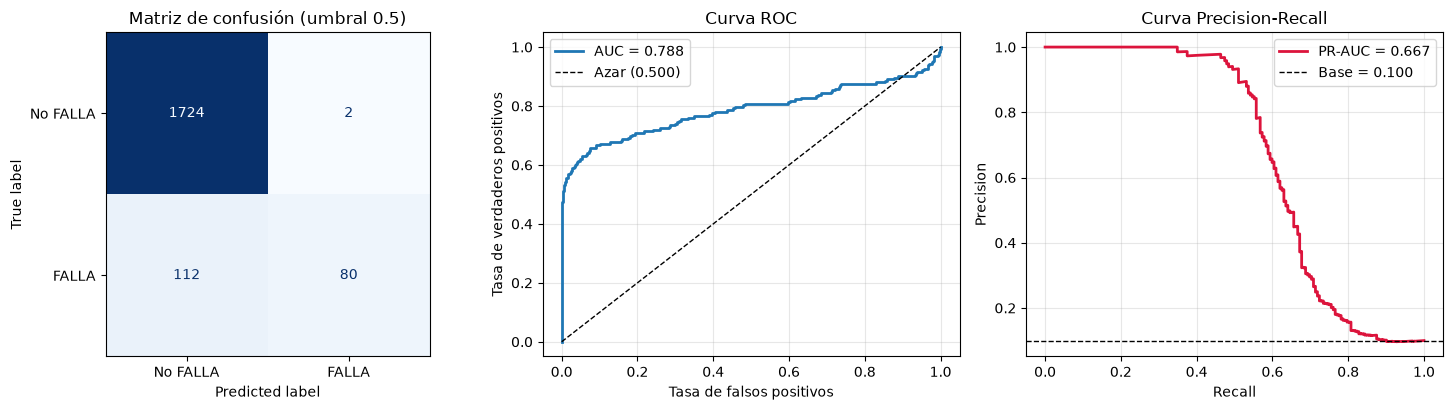

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_te, pred_05, display_labels=["No FALLA", "FALLA"], cmap="Blues",
    colorbar=False, ax=axes[0])
axes[0].set_title("Matriz de confusión (umbral 0.5)")
axes[0].grid(False)

# Curva ROC
fpr, tpr, _ = roc_curve(y_te, proba)
axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_te, proba):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Azar (0.500)")
axes[1].set(xlabel="Tasa de falsos positivos", ylabel="Tasa de verdaderos positivos",
            title="Curva ROC")
axes[1].legend()

# Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_te, proba)
axes[2].plot(rec, prec, lw=2, color="crimson",
             label=f"PR-AUC = {average_precision_score(y_te, proba):.3f}")
axes[2].axhline(y_te.mean(), ls="--", color="k", lw=1, label=f"Base = {y_te.mean():.3f}")
axes[2].set(xlabel="Recall", ylabel="Precision", title="Curva Precision-Recall")
axes[2].legend()

plt.tight_layout()
plt.show()

# Interpretación de Resultados: Matriz de Confusión y Curvas de Evaluación

Este análisis detalla el comportamiento del modelo de clasificación para la detección de fallas en equipos basándose en tres visualizaciones clave:

## 1. Matriz de Confusión (Umbral 0.5)
La matriz evalúa el desempeño categórico del modelo utilizando un umbral de decisión estándar de $0.5$:

* **Verdaderos Negativos ($1724$):** Equipos operativos sanos que el modelo identificó correctamente como normales.
* **Falsos Positivos ($2$):** Equipos sanos catalogados erróneamente como fallidos (falsas alarmas muy bajas, lo que demuestra alta precisión).
* **Falsos Negativos ($112$):** Fallas reales que el modelo **no logró detectar**, clasificándolas por error como equipos normales (un riesgo operativo importante).
* **Verdaderos Positivos ($80$):** Anomalías o fallas reales que el modelo identificó con éxito.

## 2. Curva ROC (Receiver Operating Characteristic)
* **Métrica AUC (0.788):** El área bajo la curva es de $0.788$, lo que indica una **buena capacidad discriminativa** general del modelo para separar los equipos sanos de los defectuosos en comparación con una línea base aleatoria ($0.500$).
* **Comportamiento:** La curva se eleva rápidamente hacia la esquina superior izquierda, mostrando que el modelo puede alcanzar una alta tasa de verdaderos positivos manteniendo controlada la tasa de falsos positivos.

## 3. Curva Precision-Recall (PR-AUC)
Dado que el dataset presenta un fuerte desbalance de clases (la línea base de fallas es de apenas el $10\%$ o $0.100$), esta curva es la más informativa para evaluar el rendimiento en la clase minoritaria:
* **PR-AUC (0.667):** Supera ampliamente la línea base del dataset ($0.100$), confirmando que el modelo es altamente efectivo para priorizar alertas de fallas reales.
* **Análisis de umbral:** La curva muestra cómo desciende la precisión a medida que exigimos mayor exhaustividad (*recall*), permitiendo al equipo técnico sintonizar el umbral de probabilidad ideal según la criticidad de la operación industrial.